# Use NWM topology to analyze gage pairs
This notebook was adapted from original work by James Halgren (GitHub @jameshalgren).

This notebook demonstrates accessing the National Water Model (NWM) topological definition of the NWM channel routing simulation. Using these topological relationships, we can find all possible connected pairs of reaches with gages in the USGS CONUS river network and analyze data about the paths between gages. Then, we can subset the results to analyze pairs of gages in the CAMELS dataset.

- RouteLink_CONUS.nc sourced from https://www.nco.ncep.noaa.gov/pmb/codes/nwprod/nwm.v3.0.17/parm/domain/RouteLink_CONUS.nc. (note: the version number is not static and gets updated frequently (v3.0.xx))
- usgs_inactive_sites_Oct01_2024.txt sourced from https://github.com/DualEarth/qkrig/blob/main/data/usgs_inactive_sites_Oct01_2024.txt
- basin_set_full_res folder containing HCDN_nhru_final_671 shapefile sourced from https://zenodo.org/records/15529996 (basin_set_full_res.zip)

Note: the source for RouteLink may change as the NWM gets updated by NOAA-OWP. Previous versions are not available for download.

Adapted by Nolan Parker (GitHub @nolanjparker)

In [1]:
import xarray as xr
import numpy as np
import geopandas as gpd
import os
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from dataretrieval import waterdata
from datetime import datetime, timedelta, timezone
import pandas as pd

In [2]:
routelink_ds = xr.open_dataset("RouteLink_CONUS.nc")

In [3]:
routelink_ds

<xarray.Dataset> Size: 269MB
Dimensions:            (feature_id: 2776734)
Coordinates:
    lon                (feature_id) float32 11MB ...
    lat                (feature_id) float32 11MB ...
Dimensions without coordinates: feature_id
Data variables: (12/21)
    link               (feature_id) int32 11MB ...
    from               (feature_id) int32 11MB ...
    to                 (feature_id) int32 11MB ...
    alt                (feature_id) float32 11MB ...
    order              (feature_id) int32 11MB ...
    Qi                 (feature_id) float32 11MB ...
    ...                 ...
    gages              (feature_id) |S15 42MB ...
    Kchan              (feature_id) int16 6MB ...
    ascendingIndex     (feature_id) int32 11MB ...
    nCC                (feature_id) float32 11MB ...
    TopWdthCC          (feature_id) float32 11MB ...
    TopWdth            (feature_id) float32 11MB ...
Attributes:
    Convention:        CF-1.6
    featureType:       timeSeries
    history:           Created Thu Sep  9 18:11:34 2021
    processing_notes:  This file was produced Thu Sep  9 16:16:38 2021 by Kev...

In [4]:
# Subset the dataset to only the columns we want

subslice = [
    "link",
    "to",
    "gages",
    "Length",
    "NHDWaterbodyComID",
]

routelink_df = routelink_ds[subslice].to_dataframe().astype({"link": int, "to": int, "Length": float, "NHDWaterbodyComID": int,})

## Create a topology
With the downloaded Route_Link, we can generate the topology of the CONUS river network

In [5]:
routelink_df = routelink_df.set_index("link")
routelink_df

,to,gages,Length,NHDWaterbodyComID,lon,lat
link,,,,,,
6635572,6635570,b' ',1070.0,-9999,-96.540199,46.228783
6635590,6635600,b' ',1117.0,-9999,-96.530647,46.213486
6635598,6635636,b' ',2303.0,-9999,-96.505341,46.201508
6635622,6635620,b' ',1119.0,-9999,-96.615021,46.200523
6635626,6635624,b' ',3171.0,-9999,-96.637161,46.195522
...,...,...,...,...,...,...
15456832,25371895,b' ',2208.0,-9999,-74.654648,44.979626
25371895,0,b' ',1712.0,-9999,-74.648621,44.996113
15448486,0,b' ',945.0,-9999,-74.504646,44.994370


In [6]:
def replace_downstreams(data, downstream_col, terminal_code):
    '''If a node is above a terminal node, set the downstream id to the negative of the current node.'''
    ds0_mask = data[downstream_col] == terminal_code
    new_data = data.copy()
    new_data.loc[ds0_mask, downstream_col] = ds0_mask.index[ds0_mask]

    # Also set negative any nodes in downstream col not in data.index
    new_data.loc[~data[downstream_col].isin(data.index), downstream_col] *= -1
    return new_data

def extract_connections(rows, target_col, terminal_codes=None):
    '''
    This function was sourced from the NOAA-OWP t-route codebase
    https://github.com/NOAA-OWP/t-route
    Extract connection network from dataframe.

    Arguments:
    ----------
    rows (DataFrame): Dataframe indexed by key_col.
    key_col    (str): Source of each edge
    target_col (str): Target of edge

    Returns:
    --------
    network (dict, int: [int]): {segment id: [list of downstream adjacent segment ids]}
    
    '''
    if terminal_codes is not None:
        terminal_codes = set(terminal_codes)
    else:
        terminal_codes = {0}

    network = {}
    for src, dst in rows[target_col].items():
        if src not in network:
            network[src] = []

        if dst not in terminal_codes:
            network[src].append(dst)
    return network

In [7]:
# Reorganize RouteLink file
routelink_df = routelink_df.sort_index()
routelink_df = replace_downstreams(routelink_df, "to", 0)

In [8]:
# Extract topology from RouteLink file
connections = extract_connections(routelink_df, "to")

## Analyze all connected pairs of gages
We can use routelink_df to find all pairs of reaches with gages in the CONUS river network that are connected by a downstream path. We can then store additional information about each pair, including the length of the path, the number of reaches in the path, and any water bodies on the path.

In [9]:
# Convert the gagestr column of routelink_df into strings
gagestrs = []
for i in range(len(routelink_df)):
    gagestrs.append(str(routelink_df['gages'].iloc[i]))
routelink_df['gagestr'] = gagestrs
routelink_df.head()

,to,gages,Length,NHDWaterbodyComID,lon,lat,gagestr
link,,,,,,,
101,1078719,b' ',3251.0,-9999,-94.640541,31.086876,b' '
179,181,b' ',2412.0,-9999,-67.986412,46.022163,b' '
181,1435,b' ',442.0,-9999,-67.998726,46.016491,b' '
183,185,b' ',112.0,-9999,-67.998833,46.020847,b' '
185,1065,b' ',170.0,-9999,-67.998619,46.019711,b' '


In [10]:
# First link in routelink_df does not have a gage, so we can store its gagestr value as the null value for gages
null_value = routelink_df.iloc[0]["gagestr"]

In [11]:
# Function for removing the leading non-digit characters in gagestr
# This makes it easier to check gage IDs
def only_nums_gagestr(gagestr):
    return "".join([char for char in gagestr if char.isdigit()])

In [12]:
# Add all links that have a gagestr value other than the null value to gages
# Create a dictionary with link as the key and the formatted gage ID as the value (used later for checking if gages are in CAMELS)
gages = set()
gage_lookup_dict = {}
for i in range(routelink_df.shape[0]):
    gage_id = routelink_df.iloc[i]["gagestr"]
    if gage_id != null_value:
        gage = int(routelink_df.index[i]) # Convert the link value from numpy.int64 to int
        gages.add(gage)
        gage_lookup_dict[gage] = only_nums_gagestr(gage_id) # remove the leading digits from gagestr before adding it to the dict

In [13]:
print(gage_lookup_dict)

{3109: '01030350', 3923: '01030500', 12932: '06741510', 13288: '401733105392404', 13302: '401723105400000', 13584: '402114105350101', 30580: '272524080221800', 54392: '02276998', 66922: '02277600', 83230: '254157080213800', 83454: '022907085', 87382: '022908295', 89620: '251209080350100', 89626: '251203080480600', 89628: '251154080471900', 89912: '251355080312800', 188073: '06711780', 188107: '06711618', 188199: '06710385', 188209: '06710247', 188283: '06709740', 188633: '06710605', 188637: '06711040', 188691: '06709530', 189361: '06711555', 189855: '06711570', 189861: '06711515', 189869: '06710150', 189899: '06711575', 190643: '06701900', 190819: '06701620', 190871: '06700000', 191379: '06701700', 191739: '06709000', 191765: '06708800', 191785: '06708690', 192089: '06708600', 194423: '06711565', 203757: '08470050', 206131: '08470400', 225621: '06721000', 225687: '06720990', 228553: '06720820', 229677: '394839104570300', 229709: '06714215', 229717: '06720460', 230137: '393109104464500'

In [14]:
# Create a dictionary with the length and NHDWaterbodyCOMID for each link in routelink_df for faster access
lookup_dict = routelink_df[['Length', 'NHDWaterbodyComID']].to_dict(orient='index')

In [15]:
# Print the first four links and corresponding data in lookup_dict
count = 0
for link in lookup_dict:
    if count > 3: break
    print(f"{link}: {lookup_dict[link]}")
    count += 1

101: {'Length': 3251.0, 'NHDWaterbodyComID': -9999}
179: {'Length': 2412.0, 'NHDWaterbodyComID': -9999}
181: {'Length': 442.0, 'NHDWaterbodyComID': -9999}
183: {'Length': 112.0, 'NHDWaterbodyComID': -9999}


In [16]:
# Return a list of all gages downstream from a starting gage
# Use iteration to avoid recursion limit
def get_downstream_gages_iterative(start_gage):
    downstreams = []
    visited = {start_gage}
    
    start_wb = lookup_dict[start_gage]['NHDWaterbodyComID']
    start_data = [start_gage, 0, 0, [start_wb]] if start_wb != -9999 else [start_gage, 0, 0, []]

    stack = [start_data] # [link, reaches transversed, length, water body path]

    while stack:
        curr_data = stack.pop()
        curr_link = curr_data[0]
        curr_reaches = curr_data[1]
        curr_length = curr_data[2]
        curr_wb_path = curr_data[3]

        direct_downstream = connections[curr_link][0] # Only one downstream connection per reach, so we just use the first element in this list
        if direct_downstream > 0 and direct_downstream not in visited:
            visited.add(direct_downstream)

            new_wb = lookup_dict[direct_downstream]['NHDWaterbodyComID']
            new_wb_path = curr_wb_path + [new_wb] if new_wb != -9999 and new_wb not in curr_wb_path else curr_wb_path

            stack.append([direct_downstream, curr_reaches + 1, curr_length + lookup_dict[direct_downstream]['Length'], new_wb_path])

            if direct_downstream in gages:
                downstreams.append([direct_downstream, curr_reaches, curr_length, new_wb_path])

    return downstreams

In [17]:
# Get a dictionary containing each gage with a downstream path to another gage
# Key: link value of start gage
# Value: list of downstream reachable gages (each downstream gage is a list with data about the path to it)
# Downstream list: [end gage link, reaches between start and end, length of path between start and end, list of water bodies passed through]
# Note: reaches between start and end excludes the start and end
connected_gages = {}

for gage in gages:
    downstreams = get_downstream_gages_iterative(gage)
    if downstreams:
        connected_gages[gage] = downstreams

### Inspect outputted data

In [18]:
# Print the first few gages and their corresponding downstream gages
count = 0
for gage in connected_gages:
    if count > 3:
        break
    print(f'{gage}: {connected_gages[gage]}')
    count += 1

13107201: [[13107207, 0, 0, []], [13107421, 33, 60648.0, []], [2118562, 123, 153925.0, []], [14809371, 438, 503296.0, []], [3624735, 886, 1041620.0, []], [5089904, 941, 1156307.0, []], [5092616, 980, 1262064.0, []], [7469392, 1038, 1443031.0, []], [7474830, 1088, 1684927.0, []], [19266232, 1185, 2168987.0, []], [19088319, 1257, 2496266.0, []]]
21921793: [[21919761, 8, 9058.0, []], [21920889, 66, 94643.0, [21919051]], [21928243, 172, 202984.0, [21919051]], [21813112, 261, 295048.0, [21919051]], [17916483, 375, 425836.0, [21919051, 17916173]], [19432886, 419, 516351.0, [21919051, 17916173]], [15169567, 495, 839948.0, [21919051, 17916173]]]
17956869: [[19266232, 117, 256912.0, []], [19088319, 189, 584191.0, []]]
13107207: [[13107421, 32, 56660.0, []], [2118562, 122, 149937.0, []], [14809371, 437, 499308.0, []], [3624735, 885, 1037632.0, []], [5089904, 940, 1152319.0, []], [5092616, 979, 1258076.0, []], [7469392, 1037, 1439043.0, []], [7474830, 1087, 1680939.0, []], [19266232, 1184, 216499

In [19]:
count = 0
for gage in connected_gages:
    for pair in connected_gages[gage]:
        count += 1

print(f"{count} connected pairs of gages")

82597 connected pairs of gages


## Analyze CAMELS gages

Use geopandas to open the CAMELS gages shape file as a dataframe.

In [20]:
camels_gages_df = gpd.read_file("basin_set_full_res/HCDN_nhru_final_671.shp")

Print the first few rows.

In [21]:
camels_gages_df.head()

,hru_id,ann_P,lon_cen,lat_cen,AREA,elev_mean,ave_T,july_T,Perimeter,geometry
0,1013500,0.0,-68.56551,47.01169,2.303988e+09,277.493490,NaN,NaN,647993,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4..."
1,1022500,0.0,-68.07313,44.79691,6.203873e+08,103.604200,NaN,NaN,312624,"POLYGON ((-67.97836 44.6131, -67.978 44.61303,..."
2,1030500,0.0,-68.14985,45.80527,3.676155e+09,174.433896,NaN,NaN,662248,"MULTIPOLYGON (((-67.83991 45.36614, -67.83955 ..."
3,1031500,0.0,-69.58119,45.23568,7.665447e+08,304.743490,NaN,NaN,309614,"MULTIPOLYGON (((-69.3381 45.12317, -69.338 45...."
4,1047000,0.0,-70.16213,44.98744,9.049562e+08,379.779978,NaN,NaN,310157,"POLYGON ((-70.10847 45.21669, -70.10858 45.216..."


The hru_id column contains a list of all the gage IDs in the CAMELS dataset. Convert that column to a set for easy/fast access.

In [22]:
camels_gage_ids = set(camels_gages_df['hru_id'])

In [23]:
total_camels_gages = len(camels_gage_ids)
print(total_camels_gages)

671


Some gage IDs have a length of 7. These IDs should have a zero in front to match the format in the RouteLink file. Convert camels_gage_ids to a set of strings and add the zero.

In [24]:
count = 0
camels_gage_ids_updated = set()
for gage_id in camels_gage_ids:
    if len(str(gage_id)) == 7:
        count += 1
        camels_gage_ids_updated.add(f'0{gage_id}')
    else:
        camels_gage_ids_updated.add(str(gage_id))
camels_gage_ids = camels_gage_ids_updated

In [25]:
print(f'{count} CAMELS gage IDs had a length of 7. That is {round(count/total_camels_gages * 10000)/100}% of the CAMELS gages. These gage IDs have been prepended with a zero.')

522 CAMELS gage IDs had a length of 7. That is 77.79% of the CAMELS gages. These gage IDs have been prepended with a zero.


In [26]:
# All IDs should have a length of 8 now, so this code should print nothing
for id in camels_gage_ids_updated:
    if len(id) != 8:
        print(id)

### Investigate invalid IDs

Some of the CAMELS gage IDs are not in the RouteLink file. Get a list of these invalid IDs.

In [27]:
invalid_ids = set()
for gage_id in camels_gage_ids:
    if not gage_id in gage_lookup_dict.values(): # If an ID is invalid, add it to the list
        invalid_ids.add(gage_id)
print(f'{len(invalid_ids)} invalid IDs')

21 invalid IDs


In [28]:
print(invalid_ids)

{'02246000', '02342933', '04161580', '03238500', '04127918', '02112360', '06291500', '02112120', '02430615', '02011460', '03592718', '09035800', '11230500', '06154410', '11237500', '04233000', '02125000', '03338780', '10336740', '12383500', '12388400'}


There is no obvious patten when visually inspecting these IDs. One possibility is that these gages are inactive. We can check against a list of inactive sites as of October 1, 2024.

In [29]:
# The inactive sites text file contains some gage IDs with a length of 7.
# Prepend these gage IDs with a zero in the file to match the RouteLink formatting.

with open('usgs_inactive_sites_Oct01_2024.txt', 'r') as fr, open('temp.txt', 'w') as fw:
    for line in fr:
        if len(line) == 8: # 8 instead of 7 because line includes '\n' character
            fw.write(f'{0}{line}')
        else:
            fw.write(line)

os.replace('temp.txt', 'usgs_inactive_sites_Oct01_2024.txt')

Check if any of these inactive IDs are CAMELS gages.

In [30]:
inactive_ids = set()
with open('usgs_inactive_sites_Oct01_2024.txt', 'r') as file:
    for line in file:
        curr_id = line.strip()
        if curr_id in camels_gage_ids:
            inactive_ids.add(curr_id)

In [31]:
print(f'{len(inactive_ids)} inactive CAMELS gages')

34 inactive CAMELS gages


Check if any of the inactive CAMELS gages are also invalid (missing from the RouteLink file).

In [32]:
count = 0
for inactive_id in inactive_ids:
    if inactive_id in invalid_ids: # Check if the inactive ID is also invalid
        count += 1
print(f'{count} of the invalid IDs are inactive. This is {round(count/len(invalid_ids) * 10000)/100}% of the invalid IDs.')

18 of the invalid IDs are inactive. This is 85.71% of the invalid IDs.


Most (~86%) of the invalid IDs are also inactive. This could partially explain why some IDs are missing from the RouteLink file.

### Check if missing CAMELS gages exist in RouteLink under another ID

Another possibility is that some of the missing gages are included in the CONUS RouteLink file but have a different ID number in the RouteLink than in the CAMELS shape file. We can determine if this is the case by checking the distance of each gage in the RouteLink file to each invalid gage by comparing the latitudes and longitudes of the gages. We can use the USGS dataretrieval library to get the latitude and longitudes of the CAMELS gages that are missing from the RouteLink file.

In [33]:
# Due to request limits, we first split the CAMELS gage IDs list into chunks of 30
size = 30
camels_chunked = [list(camels_gage_ids)[i:i+size] for i in range(0, len(camels_gage_ids), size)]

In [34]:
# Using dataretrieval.waterdata, we can get positional information and time information about each of the CAMELS gages
results = []
for chunk in camels_chunked:
    data, metadata = waterdata.get_monitoring_locations(monitoring_location_number=chunk, properties=['geometry', 'monitoring_location_number'])

    # Fomat the longitude and latitude data from get_monitoring_locations into separate columns and add them to the DataFrame
    data['lat'] = data.geometry.y
    data['lon'] = data.geometry.x
    data = data.drop(columns=['geometry'])
    data = data.rename(columns={'monitoring_location_number': 'gage_id'})

    # We can also request time data about the most recent recorded measurements to confirm whether gages are active
    monitoring_location_ids = [f'USGS-{gage_id}' for gage_id in chunk]
    data2, metadata2 = waterdata.get_time_series_metadata(monitoring_location_id=monitoring_location_ids, properties=['monitoring_location_id', 'end_utc'])
    data2 = data2.groupby('monitoring_location_id')['end_utc'].max().reset_index() # Each type of measurement has a separate row, but we only need the time of the most recent measurement to determine if a site is active
    data['end_utc'] = data2['end_utc']
    cutoff = datetime.now(timezone.utc) - timedelta(days=7) # If the most recent measurement was within 7 days of today, we will consider the gage to be active
    data['is_active'] = data2['end_utc'] >= cutoff

    results.append(data) # Add the results from this chunk to the results list

results = pd.concat(results, ignore_index=True) # Combine the results of each chunk into one DataFrame

In [35]:
results = results.set_index('gage_id') # Set the index to gage_id

In [36]:
# For each CAMELS gage missing from the RouteLink, find its distance to each gage in the RouteLink to determine if it is included in the RouteLink under another ID.
dists = {}

for invalid_id in invalid_ids:
    invalid_id_lat = results.at[invalid_id, 'lat'] # Get the latitude of the current missing gage from the results DataFrame
    invalid_id_lon = results.at[invalid_id, 'lon'] # Get the longitude
    for link in gage_lookup_dict.keys():
        gage_id = gage_lookup_dict[link]
        lat = routelink_df.loc[link, 'lat'] # Get the latitude of the current gage from the RouteLink
        lon = routelink_df.loc[link, 'lon'] # Get the longitude
        dist = geodesic((lat, lon), (invalid_id_lat, invalid_id_lon)).km # Calculate its distance to the current missing gage
        dists[dist] = [invalid_id, gage_id, float(invalid_id_lat), float(invalid_id_lon), float(lat), float(lon)] # Store this distance along with a list of data in the dists dictionary
        # Each dist is stored in the dictionary as follows:
        # dist: [missing_gage_id, current_gage_id, missing_gage_lat, missing_gage_lon, current_gage_lat, current_gage_lon]

sorted_dist_data = {k: dists[k] for k in sorted(dists)} # Sort the distances in the dictionary in ascending order

In [37]:
# Print the first four distances and corresponding data in sorted_dist_data
count = 0
for dist in sorted_dist_data:
    if count > 3: break
    print(f"{dist}: {sorted_dist_data[dist]}")
    count += 1

0.4234134407916616: ['04127918', '04127917', 46.1858505313516, -84.5978262471366, 46.182960510253906, -84.59425354003906]
0.6710869782541512: ['09035800', '09035900', 39.8005418119377, -106.026406598448, 39.795433044433594, -106.03059387207031]
1.323723932005835: ['09035800', '09035700', 39.8005418119377, -106.026406598448, 39.7893180847168, -106.02119445800781]
2.9099590469975607: ['10336740', '10336730', 39.0665747760839, -119.935460476658, 39.08759307861328, -119.91536712646484]


It appears that some gages in the RouteLink are very close to some of the missing gages. One gage is within 0.5 kilometers of a missing gage. However, it appears that the gage IDs in each of these first four pairs are very similar but not exactly the same. It seems plausible that the gages have similar IDs because they are in the same group/near each other. It is difficult to say for certain whether or not the gages in these pairs are the same gage.

### Reexamine inactive gage data with dataretrieval.waterdata

We can use the time data we retrieved earlier with waterdata to check if a gage is active, allowing us to confirm the data from usgs_inactive_sites_Oct01_2024.txt

In [38]:
# Get a DataFrame that only includes inactive gages
inactive_gages = results[results.is_active == False]
print(f'{len(inactive_gages)} inactive gages')
inactive_gages.head()

35 inactive gages


,lat,lon,end_utc,is_active
gage_id,,,,
04127918,46.185851,-84.597826,2012-05-30 08:45:00+00:00,False
02112360,36.311389,-80.807222,2014-10-01 07:45:00+00:00,False
13240000,44.913611,-115.997222,2025-10-01 12:45:00+00:00,False
02112120,36.250278,-81.044444,2014-10-14 07:45:00+00:00,False
03238500,38.858125,-83.928539,2012-01-16 05:00:00+00:00,False


Note that the number of inactive CAMELS gages from the waterdata library (35) is slightly different than the number of inactive CAMELS gages in the text file (34). This is likely because the textfile is from Octover 1, 2024, whereas the data from waterdata is current.

In [39]:
count = 0
for gage_id in invalid_ids:
    if gage_id in inactive_gages.index:
        count += 1
print(f'{count} of the invalid IDs are inactive ({round(count/len(invalid_ids) * 10000)/100}%) according to waterdata. According to the text file, 18 are inactive.')

17 of the invalid IDs are inactive (80.95%) according to waterdata. According to the text file, 18 are inactive.


Since the data from waterdata is more recent, we will use that data to add any inactive CAMELS gages included in the RouteLink to the list of invalid CAMELS gages.

In [40]:
for gage_id in inactive_gages.index:
    if gage_id not in invalid_ids:
        invalid_ids.add(gage_id)

In [41]:
print(f'There are now {len(invalid_ids)} invalid CAMELS gages, including 4 active CAMELS gages that are missing from the RouteLink file.')

There are now 39 invalid CAMELS gages, including 4 active CAMELS gages that are missing from the RouteLink file.


### Analyze CAMELS gage pairs

Now that we have a list of valid CAMELS gage IDs, we can create dictionaries for pairs of CAMELS gages, where both the upstream and downstream gages are CAMELS gages.

We will create one dictionary that has overlapping pairs. For exmaple, if A connects to B, B connects to C, and A connects to C, we will store all three pairs even though (A, C) overlaps (A, B).
We will create another dictionary that does not include overlapping pairs.

Gage IDs are more useful than link values for the purposes of this task, so we will use gage IDs in place of link values from the previous connected_gages list.

In [42]:
# Get a dictionary containing each CAMELS gage with a downstream path to another CAMELS gage
# Key: gage ID of start gage
# Value: list of downstream reachable CAMELS gages (each downstream CAMELS gage is a list with data about the path to it)
# Downstream CAMELS gage list: [end gage ID, reaches between start and end, length of path between start and end, list of water bodies passed through]
camels_connected_gages = {}
# Get a dictionary of CAMELS gage pairs excluding overlapping pairs
# Key: gage ID of start gage
# Value: first downstream reachable CAMELS (a list with data about the path to it)
# Downstream list: [end gage ID, reaches between start and end, length of path between start and end, list of water bodies passed through]
non_overlapping_camels_pairs = {}

for upstream_gage in connected_gages: # We create these dictionaries by looping through the previous connected_gages list and adding any pairs that meet the requirements (both CAMELS gages, non-overlapping for the second dictionary)
    upstream_gage_id = gage_lookup_dict[upstream_gage]
    if upstream_gage_id in camels_gage_ids: # We use camels_gage_ids rather than valid_camels_gage_ids because we'll investigate the validity of paired gages later
        camels_downstreams = []
        for downstream_gage_list in connected_gages[upstream_gage]:
            downstream_gage_id = gage_lookup_dict[downstream_gage_list[0]] # downstream_gage_list[0] is the link id
            if downstream_gage_id in camels_gage_ids:
                new_downstream_gage_list = downstream_gage_list.copy()
                new_downstream_gage_list[0] = downstream_gage_id # Modify the copy of the downstream gage's list to store the gage ID instead of the link ID
                camels_downstreams.append(new_downstream_gage_list) # Since this downstream gage is in CAMELS, we add its new list to the list of downstream CAMELS connections
        if camels_downstreams:
            camels_connected_gages[upstream_gage_id] = camels_downstreams
            non_overlapping_camels_pairs[upstream_gage_id] = camels_downstreams[0] # Only store the first downstream CAMELS gage to avoid overlaps

In [43]:
num_camels_pairs_with_overlaps = 0
for camels_gage_id in camels_connected_gages:
    num_camels_pairs_with_overlaps += len(camels_connected_gages[camels_gage_id])
print('Number of CAMELS gage pairs including overlaps: ', num_camels_pairs_with_overlaps)

Number of CAMELS gage pairs including overlaps:  51


In [44]:
print('Number of CAMELS gage pairs excluding overlaps: ', len(non_overlapping_camels_pairs))

Number of CAMELS gage pairs excluding overlaps:  47


In [45]:
print(camels_connected_gages)

{'01543000': [['01543500', 10, 15866.0, []]], '02015700': [['02016000', 49, 94281.0, []]], '01605500': [['01606500', 34, 56531.0, []]], '02297155': [['02297310', 16, 42430.0, []]], '06352000': [['06353000', 94, 262643.0, []], ['06354000', 130, 347771.0, []]], '13338500': [['13340000', 48, 54733.0, []]], '06353000': [['06354000', 35, 81213.0, []]], '02017500': [['02018000', 40, 58914.0, []]], '03066000': [['03069500', 32, 27548.0, []]], '05584500': [['05585000', 47, 74897.0, []]], '08377900': [['08378500', 5, 8215.0, []]], '07196900': [['07197000', 34, 44440.0, []]], '09492400': [['09494000', 41, 40900.0, []]], '06889200': [['06889500', 18, 24730.0, []]], '06440200': [['06441500', 136, 265910.0, []]], '03161000': [['03164000', 113, 111518.0, []]], '06404000': [['06406000', 12, 20002.0, []]], '07291000': [['07292500', 49, 52538.0, []]], '03180500': [['03182500', 30, 71759.0, []]], '08070000': [['08070200', 4, 26183.0, []]], '03281100': [['03281500', 42, 84511.0, []]], '05056000': [['0505

In [46]:
print(non_overlapping_camels_pairs)

{'01543000': ['01543500', 10, 15866.0, []], '02015700': ['02016000', 49, 94281.0, []], '01605500': ['01606500', 34, 56531.0, []], '02297155': ['02297310', 16, 42430.0, []], '06352000': ['06353000', 94, 262643.0, []], '13338500': ['13340000', 48, 54733.0, []], '06353000': ['06354000', 35, 81213.0, []], '02017500': ['02018000', 40, 58914.0, []], '03066000': ['03069500', 32, 27548.0, []], '05584500': ['05585000', 47, 74897.0, []], '08377900': ['08378500', 5, 8215.0, []], '07196900': ['07197000', 34, 44440.0, []], '09492400': ['09494000', 41, 40900.0, []], '06889200': ['06889500', 18, 24730.0, []], '06440200': ['06441500', 136, 265910.0, []], '03161000': ['03164000', 113, 111518.0, []], '06404000': ['06406000', 12, 20002.0, []], '07291000': ['07292500', 49, 52538.0, []], '03180500': ['03182500', 30, 71759.0, []], '08070000': ['08070200', 4, 26183.0, []], '03281100': ['03281500', 42, 84511.0, []], '05056000': ['05057000', 51, 153410.0, []], '01666500': ['01667500', 7, 15349.0, []], '0706600

Get a set containing each unique CAMELS gage paired with another CAMELS gage.

In [47]:
unique_paired_camels_gages = set()
for gage in non_overlapping_camels_pairs:
    unique_paired_camels_gages.add(gage)
    unique_paired_camels_gages.add(non_overlapping_camels_pairs[gage][0])

In [48]:
print(f'There are {len(unique_paired_camels_gages)} unique CAMELS gages that connect, either upstream or downstream, to another CAMELS gage.')

There are 87 unique CAMELS gages that connect, either upstream or downstream, to another CAMELS gage.


Investigate whether any of these unique CAMELS gages are invalid.

In [49]:
count = 0
for gage in unique_paired_camels_gages:
    if gage in invalid_ids:
        count += 1
print(f'{count} unique paired CAMELS gages are invalid.')

0 unique paired CAMELS gages are invalid.


This is an interesting result. Although 18 inactive CAMELS gages exist in the RouteLink file (35 total inactive gages - 17 inactive gages missing from the RouteLink = 18 inactive CAMELS gages in the file), none of these gages connect to another CAMELS gage. Let's calculate the chance of this occurring randomly.

In [50]:
p_of_paired = len(unique_paired_camels_gages)/(len(camels_gage_ids) - 21) # Subtract the 21 missing gages from total CAMELS gages
p_of_18_unpaired = (1 - p_of_paired) ** 18
print(f'There is a {round(p_of_18_unpaired * 10000)/100}% chance of 18 randomly-selected, valid CAMELS gages all not being paired with other CAMELS gages.')

There is a 7.53% chance of 18 randomly-selected, valid CAMELS gages all not being paired with other CAMELS gages.


It is unlikely, though not impossible, that all 18 of the inactive but valid CAMELS gages randomly weren't paired with any other CAMELS gages. One possible explanation is that inactive gages are generally less deeply connected in the network of reaches.

### Tracing the path of a gage pair

This section confirms results by tracing the path of one of the CAMELS gage pairs to confirm that the pair is valid.

In [51]:
print(camels_connected_gages)

{'01543000': [['01543500', 10, 15866.0, []]], '02015700': [['02016000', 49, 94281.0, []]], '01605500': [['01606500', 34, 56531.0, []]], '02297155': [['02297310', 16, 42430.0, []]], '06352000': [['06353000', 94, 262643.0, []], ['06354000', 130, 347771.0, []]], '13338500': [['13340000', 48, 54733.0, []]], '06353000': [['06354000', 35, 81213.0, []]], '02017500': [['02018000', 40, 58914.0, []]], '03066000': [['03069500', 32, 27548.0, []]], '05584500': [['05585000', 47, 74897.0, []]], '08377900': [['08378500', 5, 8215.0, []]], '07196900': [['07197000', 34, 44440.0, []]], '09492400': [['09494000', 41, 40900.0, []]], '06889200': [['06889500', 18, 24730.0, []]], '06440200': [['06441500', 136, 265910.0, []]], '03161000': [['03164000', 113, 111518.0, []]], '06404000': [['06406000', 12, 20002.0, []]], '07291000': [['07292500', 49, 52538.0, []]], '03180500': [['03182500', 30, 71759.0, []]], '08070000': [['08070200', 4, 26183.0, []]], '03281100': [['03281500', 42, 84511.0, []]], '05056000': [['0505

In [52]:
start_gage_id = '01543000'
end_gage_id = '01543500'
start_gage_link = next((k for k, v in gage_lookup_dict.items() if v == start_gage_id))
print(f'start gage link - {start_gage_link}')
end_gage_link = next((k for k, v in gage_lookup_dict.items() if v == end_gage_id))
curr_link = start_gage_link
total_length = 0
i = 1
while True:
    curr_link = connections[curr_link][0]
    if curr_link == end_gage_link: break
    curr_length = lookup_dict[curr_link]['Length']
    total_length += curr_length
    print(f'{i} - {curr_link}. Length: {curr_length}. Total length so far: {total_length}')
    i += 1
print(f'end gage link - {curr_link}. Total path length: {total_length}')

start gage link - 8127529
1 - 8127533. Length: 902.0. Total length so far: 902.0
2 - 8127539. Length: 546.0. Total length so far: 1448.0
3 - 8127543. Length: 1318.0. Total length so far: 2766.0
4 - 8127553. Length: 5097.0. Total length so far: 7863.0
5 - 8127547. Length: 772.0. Total length so far: 8635.0
6 - 8127551. Length: 314.0. Total length so far: 8949.0
7 - 8127555. Length: 161.0. Total length so far: 9110.0
8 - 8127705. Length: 3075.0. Total length so far: 12185.0
9 - 8127577. Length: 3641.0. Total length so far: 15826.0
10 - 8130201. Length: 40.0. Total length so far: 15866.0
end gage link - 8127609. Total path length: 15866.0


This path length and number of reaches between gages matches the info in the camels_connected_gages dictionary.

## Plot data about pairs

We will make two graphs: one for the number of reaches between CAMELS gages including overlapping pairs and one excluding overlapping pairs.

In [53]:
reaches_between_camels_overlapping = []

for gage in camels_connected_gages:
    for gage_pair in camels_connected_gages[gage]:
        reaches_between_camels_overlapping.append(gage_pair[1])

In [54]:
reaches_between_camels_non = []

for gage in non_overlapping_camels_pairs:
    reaches_between_camels_non.append(non_overlapping_camels_pairs[gage][1])

In [55]:
# Function for making the graphs since this code is used twice

def make_graph(input_list, graph_name):
    # Define custom bins: 0-9, 10-19, ..., 80-89, 90-100, and 100+
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, np.inf]
    labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', 
            '60-69', '70-79', '80-89', '90-99', '100+']

    reaches_between = np.array(input_list) 
    counts, _ = np.histogram(reaches_between, bins=bins)

    x_pos = np.arange(len(counts))
    bar_width = 0.5

    plt.figure(figsize=(15, 6))
    plt.bar(x_pos, counts, width=bar_width)

    plt.xticks(x_pos, labels, rotation=45)
    plt.title('Reaches Between Gages')
    plt.xlabel('Number of reaches')
    plt.ylabel('Number of CAMELS pairs')

    plt.tight_layout()
    plt.savefig(f'camels_gage_pair_graphs/{graph_name}.png')

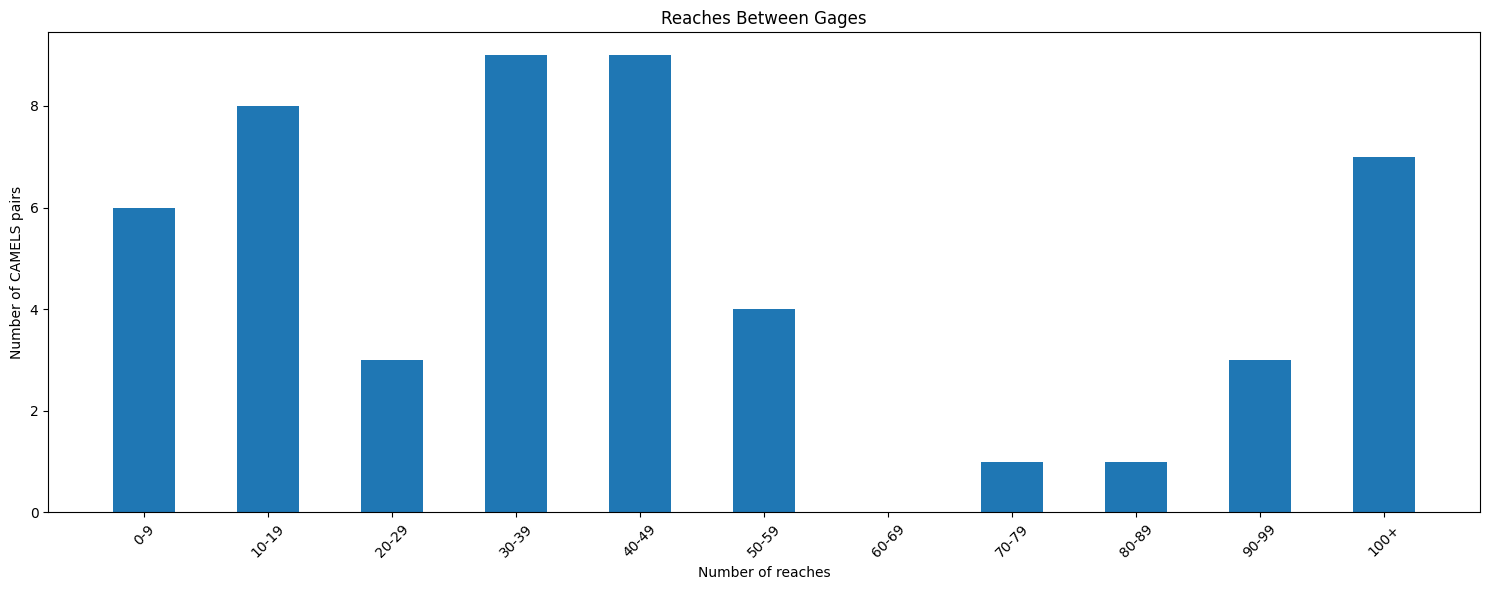

In [56]:
# Graph of reaches between pairs for CAMELS pairs including overlaps

make_graph(reaches_between_camels_overlapping, 'reaches_between_camels_with_overlaps_histogram')

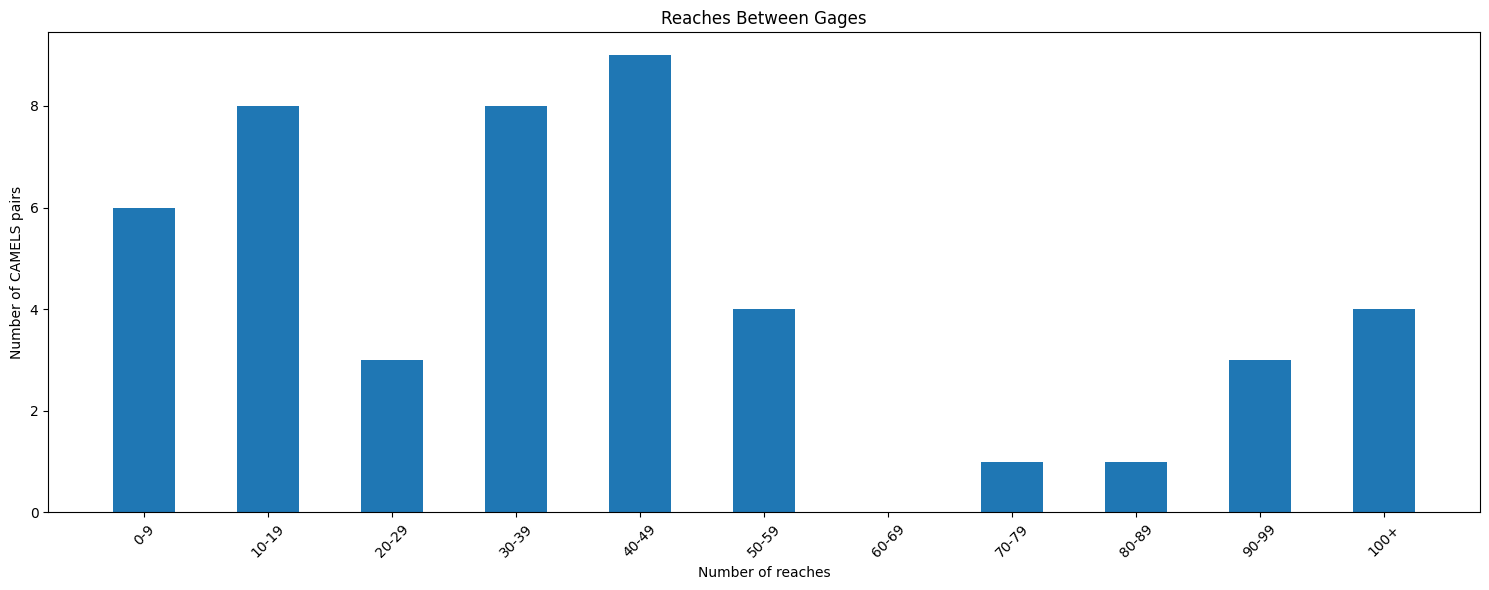

In [57]:
# Graph of reaches between pairs for CAMELS pairs excluding overlaps

make_graph(reaches_between_camels_non, 'reaches_between_camels_no_overlaps_histogram')